<a href="https://colab.research.google.com/github/jessxleee/SIT-UofG-QC-Assignment/blob/main/BB84-Plain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [118]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.



In [119]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

1.  Setup & Quantum Random Bit Generator

In [120]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

simulator = AerSimulator()

# ── Protocol settings ──────────────────────────────────────────────────────
TEST_FRACTION    = 0.5   # proportion of sifted key used for error checking
ATTACK_THRESHOLD = 0.1   # abort if error rate exceeds this

def quantum_random_bit():
    """Generate a truly random bit by measuring |+⟩"""
    qc = QuantumCircuit(1, 1) # 1 qubit, 1 classical bit
    qc.h(0)                   # Hadamard: |0⟩ → 1/√2 (|0⟩ + |1⟩)
    qc.measure(0, 0)          # Collapse the superposition
    result = simulator.run(qc, shots=1).result()
    return int(list(result.get_counts().keys())[0])

def quantum_random_bits(n):
    return [quantum_random_bit() for _ in range(n)]

2. Alice randomly chooses its data bits and bases and encodes her qubits

In [121]:
N = 100  # number of qubits to send

alice_bits  = quantum_random_bits(N)   # the secret bits
alice_bases = quantum_random_bits(N)   # 0 = rectilinear (+), 1 = diagonal (×)

print("Alice bits: ", alice_bits)
print("Alice bases:", alice_bases)

def encode_qubit(bit, basis):
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)          # flip to |1⟩
    if basis == 1:
        qc.h(0)          # rotate to diagonal basis
    return qc

Alice bits:  [1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0]
Alice bases: [0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0]


3. Bob measures the received qubits

In [122]:
bob_bases = quantum_random_bits(N)

def measure_qubit(qc, basis):
    """Bob measures in his chosen basis"""
    if basis == 1:
        qc.h(0)          # rotate back from diagonal
    qc.measure(0, 0)
    result = simulator.run(qc, shots=1).result()
    return int(list(result.get_counts().keys())[0])

bob_results = []
for i in range(N):
    qc = encode_qubit(alice_bits[i], alice_bases[i])
    bit = measure_qubit(qc, bob_bases[i])
    bob_results.append(bit)

print("Bob bases:  ", bob_bases)
print("Bob results:", bob_results)

Bob bases:   [1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0]
Bob results: [1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0]


4. Sifting (Classical Channel)

In [123]:
# === SIFTING ===
sifted_alice = []
sifted_bob   = []

for i in range(N):
    if alice_bases[i] == bob_bases[i]:   # bases matched
        sifted_alice.append(alice_bits[i])
        sifted_bob.append(bob_results[i])

print(f"Sifted key length: {len(sifted_alice)} bits")
print("Alice sifted key: ", sifted_alice)
print("Bob sifted key:   ", sifted_bob)

Sifted key length: 56 bits
Alice sifted key:  [1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0]
Bob sifted key:    [1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0]


5. Error Checking - Randomly select test positions using quantum randomness

In [124]:
def pick_test_indices(pool_size, target_count):
    selected = set()
    rounds   = 0

    while len(selected) < target_count and rounds < 10:
        flips = quantum_random_bits(pool_size)
        for idx, flip in enumerate(flips):
            if flip == 1 and idx not in selected:
                selected.add(idx)
            if len(selected) == target_count:
                break
        rounds += 1

    # Deterministic fallback — only fills any remaining gap, not used for randomness
    for idx in range(pool_size):
        if len(selected) == target_count:
            break
        selected.add(idx)

    return sorted(selected)


if len(sifted_alice) == 0:
    test_size    = 0
    test_indices = []
    errors       = 0
    error_rate   = 1.0
else:
    test_size    = max(1, math.floor(len(sifted_alice) * TEST_FRACTION))
    test_indices = pick_test_indices(len(sifted_alice), test_size)

    errors     = sum(sifted_alice[i] != sifted_bob[i] for i in test_indices)
    error_rate = errors / test_size

# Build final key from positions NOT used for testing
final_alice_key = [sifted_alice[i] for i in range(len(sifted_alice)) if i not in test_indices]
final_bob_key   = [sifted_bob[i]   for i in range(len(sifted_bob))   if i not in test_indices]

attack_detected = error_rate > ATTACK_THRESHOLD
keys_match      = final_alice_key == final_bob_key


6. BB84 Summary


In [125]:

print("=" * 45)
print("       BB84 PROTOCOL — SECURITY REPORT")
print("=" * 45)
print(f"  Qubits sent:          {N}")
print(f"  Sifted key length:    {len(sifted_alice)} bits")
print(f"  Test bits sampled:    {test_size} bits")
print(f"  Errors found:         {errors}/{test_size}")
print(f"  Error rate:           {error_rate:.0%}")
print(f"  Detection threshold:  {ATTACK_THRESHOLD:.0%}")
print(f"  Attack detected:      {'YES' if attack_detected else 'NO'}")
print(f"  Final key length:     {len(final_alice_key)} bits")
print(f"  Keys match:           {'YES ' if keys_match else 'NO'}")
print("-" * 45)

if error_rate > ATTACK_THRESHOLD:
    print("Key exchange ABORTED. Do not use key.")
else:
    print(f" No attack detected. Key length: {len(final_key)} bits")
    print(f"  Alice final key: {final_alice_key}")
    print(f"  Bob   final key: {final_bob_key}")

       BB84 PROTOCOL — SECURITY REPORT
  Qubits sent:          100
  Sifted key length:    56 bits
  Test bits sampled:    28 bits
  Errors found:         0/28
  Error rate:           0%
  Detection threshold:  10%
  Attack detected:      NO
  Final key length:     28 bits
  Keys match:           YES 
---------------------------------------------
 No attack detected. Key length: 40 bits
  Alice final key: [1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0]
  Bob   final key: [1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0]


7. Quantum Circuit Diagram

Example: Alice sends bit=1 in diagonal basis; Bob measures in diagonal basis (bases match)


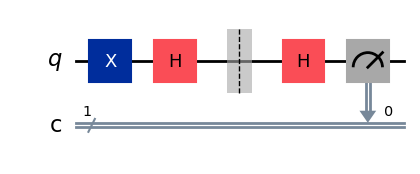

In [126]:
def bb84_qubit_circuit(alice_bit, alice_basis, bob_basis):
    qc = QuantumCircuit(1, 1)

    if alice_bit == 1:
        qc.x(0)           # encode bit value
    if alice_basis == 1:
        qc.h(0)           # rotate to diagonal basis

    qc.barrier()          # visual separator: Alice | Bob

    if bob_basis == 1:
        qc.h(0)           # Bob rotates back before measuring
    qc.measure(0, 0)
    return qc

print("Example: Alice sends bit=1 in diagonal basis; Bob measures in diagonal basis (bases match)")
bb84_qubit_circuit(1, 1, 1).draw('mpl')


8. Statistics Bar Graph

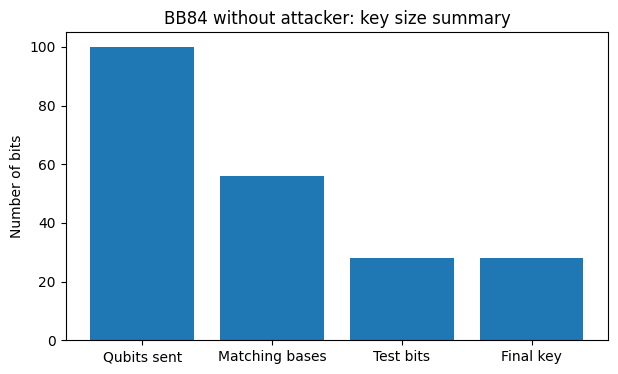

In [127]:
import matplotlib.pyplot as plt

labels = ["Qubits sent", "Matching bases", "Test bits", "Final key"]
values = [N, len(sifted_alice), test_size, len(final_alice_key)]

plt.figure(figsize=(7, 4))
plt.bar(labels, values)
plt.title("BB84 without attacker: key size summary")
plt.ylabel("Number of bits")
plt.show()



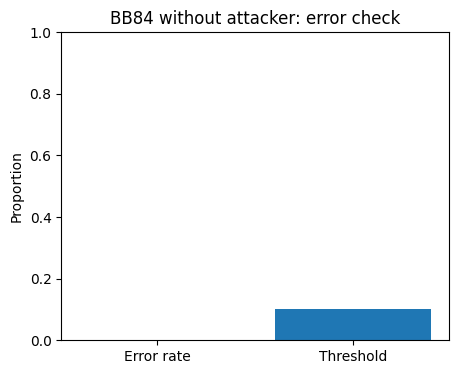

In [128]:
plt.figure(figsize=(5, 4))
plt.bar(["Error rate", "Threshold"], [error_rate, ATTACK_THRESHOLD])
plt.title("BB84 without attacker: error check")
plt.ylabel("Proportion")
plt.ylim(0, 1)

plt.show()
